In [1]:
import numpy as np
from collections import Counter
import math


In [4]:
#Emperical PMF of X
n=10
m=15
k=5
N=100000

population=np.array([1]*n+[0]*m)

X_samples=[]
Y_samples=[]

for _ in range(N):
    committee=np.random.choice(population,size=k,replace=False)
    x=np.sum(committee)
    y=k-x
    X_samples.append(x)
    Y_samples.append(y)

emperical=Counter(X_samples)
print(emperical)

for key in emperical:
    emperical[key]/=N

print("emperical PMF of X:",emperical)



Counter({np.int64(2): 38564, np.int64(1): 25379, np.int64(3): 23843, np.int64(4): 6043, np.int64(0): 5659, np.int64(5): 512})
emperical PMF of X: Counter({np.int64(2): 0.38564, np.int64(1): 0.25379, np.int64(3): 0.23843, np.int64(4): 0.06043, np.int64(0): 0.05659, np.int64(5): 0.00512})


In [5]:
#Theoretical PMF of X

def comb(n,k):
    return math.comb(n,k)

theorictical={}
for x in range(max(0,k-m),min(n,k)+1):
    prob=comb(n,x) * comb(m,k-x)/comb(n+m,k)

    theorictical[x]=prob

print("theoretical PMF of X:",theorictical)

theoretical PMF of X: {0: 0.05652173913043478, 1: 0.25691699604743085, 2: 0.38537549407114624, 3: 0.23715415019762845, 4: 0.05928853754940711, 5: 0.0047430830039525695}


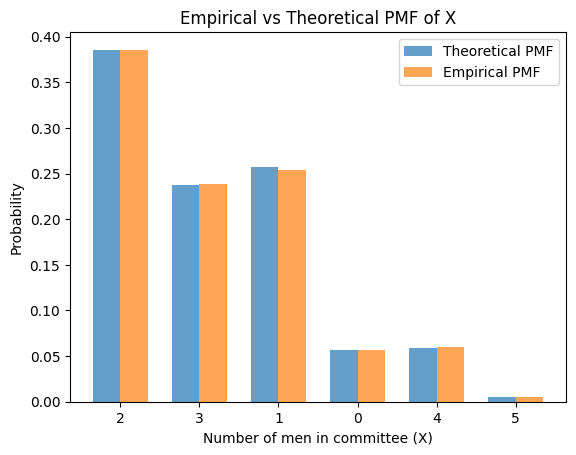

In [11]:
#Plot and compare theoretical and empirical PMF of X
import matplotlib.pyplot as plt
import numpy as np

x_values = list(emperical.keys())
emperical_values = list(emperical.values())
theoretical_values = [theorictical.get(x, 0) for x in x_values]

width = 0.35
x = np.arange(len(x_values))

plt.bar(x - width/2, theoretical_values, width, alpha=0.7, label='Theoretical PMF')
plt.bar(x + width/2, emperical_values, width, alpha=0.7, label='Empirical PMF')

plt.xticks(x, x_values)
plt.xlabel('Number of men in committee (X)')
plt.ylabel('Probability')
plt.title('Empirical vs Theoretical PMF of X')
plt.legend()
plt.show()

P(Y=k−x∣X=x)=1

In [18]:
for x in set(X_samples):
    ys_given=[Y_samples[i] for i in range(N) if X_samples[i]==x]
    
    unique_y=set(ys_given)  
    print(f"For X={x}, unique Y values: {unique_y}")
    

For X=0, unique Y values: {np.int64(5)}
For X=1, unique Y values: {np.int64(4)}
For X=2, unique Y values: {np.int64(3)}
For X=3, unique Y values: {np.int64(2)}
For X=4, unique Y values: {np.int64(1)}
For X=5, unique Y values: {np.int64(0)}


{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)}
